# Food Quality vs Urbanization
How does the urbanization of a city affect the quality of food served by restaurants on Foodpanda?


## Exploring the data

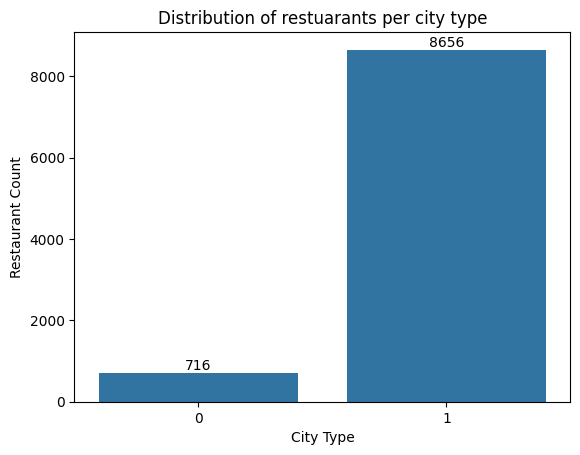

In [1]:
from data_preprocessing import ph_restos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cities = ph_restos["City"].unique();

highly_urbanized_cities = [
    'cebu city',
    'davao city davao del sur',
    'lapu-lapu city cebu',
    'makati city',
    'mandaluyong city',
    'manila',
    'marikina',
    'muntinlupa city',
    'pasay city',
    'pasig city',
    'quezon city',
    'san juan',
    'taguig city'
]

component_cities = [
    'dagupan pangasinan',
    'koronadal south cotabato',
    'malolos bulacan',
    'ormoc leyte',
    'valencia bukidnon'
]

def label_city(vector):
    if vector["City"] in highly_urbanized_cities:
        return 1
    else:
        return 0

ph_restos["HighlyUrbanized"] = ph_restos.apply(label_city, axis=1)
ph_restos.head()

ax = sns.countplot(data=ph_restos, x='HighlyUrbanized')
ax.bar_label(ax.containers[0]) # type: ignore

plt.xlabel("City Type")
plt.ylabel("Restaurant Count")
plt.title("Distribution of restuarants per city type")
plt.show()

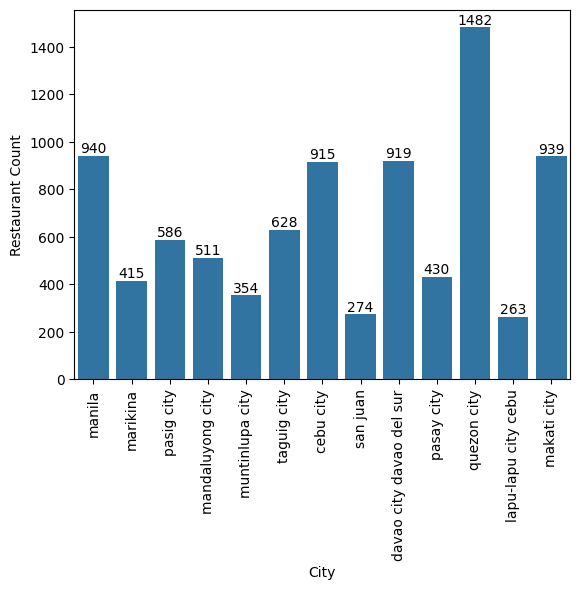

In [25]:
ax = sns.countplot(data=ph_restos[ph_restos["City"].isin(highly_urbanized_cities)], x = "City")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("City")
plt.ylabel("Restaurant Count")
plt.show()

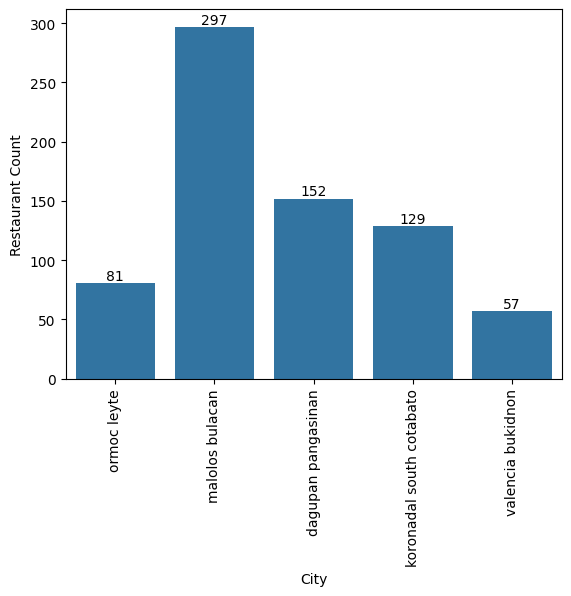

In [26]:
ax = sns.countplot(data=ph_restos[ph_restos["City"].isin(component_cities)], x = "City")
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0]) # type: ignore
plt.xlabel("City")
plt.ylabel("Restaurant Count")
plt.show()

## Determining if urbanization of a city affects the rating of restaurants
We'll be using t-test, although this assumes that the data set follows a normal distribution. Kahit di siya normally distributed, ok lng kasi Central Limit Theorem. 

Total Highly Urbanized:  8656
Total Component Cities:  716

Shapiro-Wilk Test for Highly Urbanized Cities:
Test Statistic: 0.3435944633235567
p-value: 1.866337625580115e-100

Shapiro-Wilk Test for Less Urbanized Cities:
Test Statistic: 0.3930989623886074
p-value: 1.6335223148222224e-43


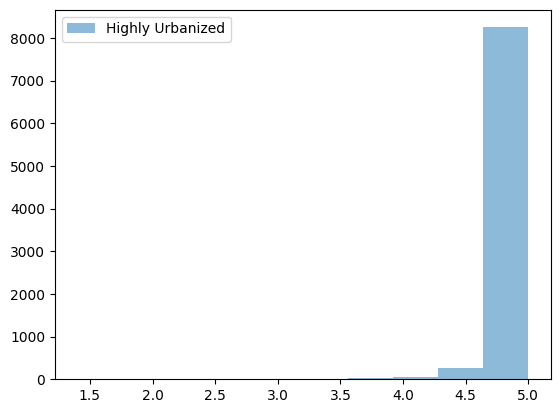


Independent Samples t-test:
t-statistic: 0.0931349185318071
p-value: 0.9257983682059079

Mann-Whitney U Test:
U-statistic: 3130783.0
p-value: 0.5888579822174669


In [13]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

ratings_highly_urbanized = ph_restos[ph_restos['HighlyUrbanized']==1]['AverageRating']
ratings_component = ph_restos[ph_restos['HighlyUrbanized']==0]['AverageRating']

print("Total Highly Urbanized: ", len(ratings_highly_urbanized))
print("Total Component Cities: ", len(ratings_component))

stat_highly_urbanized, p_highly_urbanized = shapiro(ratings_highly_urbanized)
stat_less_urbanized, p_less_urbanized = shapiro(ratings_component)

print("\nShapiro-Wilk Test for Highly Urbanized Cities:")
print("Test Statistic:", stat_highly_urbanized)
print("p-value:", p_highly_urbanized)
print("\nShapiro-Wilk Test for Less Urbanized Cities:")
print("Test Statistic:", stat_less_urbanized)
print("p-value:", p_less_urbanized)

plt.hist(ratings_highly_urbanized, bins=10, alpha =0.5, label = "Highly Urbanized")
# plt.hist(ratings_component, bins=10, alpha=0.5, label="Component City")
plt.legend()
plt.show()

t_statistic, t_pvalue = ttest_ind(ratings_highly_urbanized, ratings_component)
print("\nIndependent Samples t-test:")
print("t-statistic:", t_statistic)
print("p-value:", t_pvalue)

u_statistic, u_pvalue = mannwhitneyu(ratings_highly_urbanized, ratings_component)
print("\nMann-Whitney U Test:")
print("U-statistic:", u_statistic)
print("p-value:", u_pvalue)
